#Seasonal Differences in Harbor Seal Diet
##Jessica Hughes | MS 285 Final Project


##Motivation

**Science Question:** Do harbor seal diet proportions differ between seasons (spring and fall)?

**Background Context**: It is important to understand the seasonal variability in harbor seal diets to reveal more about their foraging plasticity and adaptability. Central place foraging theory suggests that harbor seals prefer to forage near their haul-outs due to their moderate to high site fidelity, which in turn encourages a generalist diet (i.e., a more flexible diet), since there is less opportunity to be highly selective when hunting for prey. As prey abundance and composition change from one season to the next, harbor seal diets will change accordingly. Therefore, understanding the seasonal changes in diet composition will allude to the changes in the habitats that make up harbor seals’ local foraging ranges.

#Data

**Data Source and Description:**
This dataset comes from a [public dataset available on Dryad](https://datadryad.org/dataset/doi:10.5061/dryad.g23j32s) that was published in association with the following article:

Schwarz, D., Spitzer, S. M., Thomas, A. C., Kohnert, C. M., Keates, T. R., & Acevedo‐Gutiérrez, A. (2018). Large‐scale molecular diet analysis in a generalist marine mammal reveals male preference for prey of conservation concern. Ecology and Evolution, 8(19), 9889-9905. https://doi.org/10.1002/ece3.4474

The researchers took scat samples from harbor seal colonies to analyze the diet composition and recorded the sex of the individual, the sample ID, the month, season, and year the sample was collected, the site (i.e., the colony) that the sample was collected from, and the diet proportions by prey species, and diet proportions by prey order.

The original dataset is a .csv file that is posted on Dryad is 160.10 KB. However, I cleaned up the original dataset and created a new .csv file that is 125 KB using Google Spreadsheets, in which I removed the columns with diet proportions by prey order since I just want to focus on diet proportions by prey species: [Link to the data](https://docs.google.com/spreadsheets/d/11cyY0J7lKJY5X8eAhHKByFLa_lifs9Ff2XsDzJniXVM/edit?gid=0#gid=0)



**Data Preprocessing:**


Start by importing the necessary modules:

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, r2_score
from sklearn.linear_model import Perceptron, LogisticRegression

In [ ]:
home_dir = os.path.expanduser('~')

Put the files in a Google Drive folder and mount my Google Drive on Colab:

In [ ]:
if home_dir=='/root':
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


Provide a file path to the folder with the necessary files:

In [ ]:
if home_dir=='/root':
    working_dir = '/content/drive/MyDrive/MS_285/MS285_project'

Finding the needed file:

In [ ]:
if '.csv' in os.listdir(working_dir):
    print('Found MS285_project_data_harbor_seals.csv successfully!')
else:
    print('Hmmm.... couldn\'t find MS285_project_data_harbor_seals.csv')

Hmmm.... couldn't find MS285_project_data_harbor_seals.csv


In [ ]:
# read in the data
df = pd.read_csv('/content/drive/MyDrive/MS_285/MS285_project/MS285_project_data_harbor_seals.csv')

# print out the data frame head
df.head()

,Sex,Season,Site,Ad_Atlantic_Salmon,Ad_cutthroat_trout,Ad_dolly_varden,Ad_Chinook_salmon,Ad_chum_salmon,Ad_coho_salmon,Ad_pink_salmon,...,Spotted_Ratfish,Starry_Flounder,Striped_Surfperch,Surf_Smelt,Tadpole_Sculpin,Threespine_Stickleback,Walleye_Pollock,Whitebait_Smelt,Whitespotted_Greenling,Wolf_Eel
0,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0
1,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,1.567398,0.0,0.0,0
2,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.703704,18.518518,0.0,0.0,0
3,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,1.443696,0.0,0.0,0
4,M,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,42.902813,0.0,0.0,0


#Turning 'Season' into a number

In [ ]:
#Defining what 'Season' means so that I can turn the seasons into numbers in the next step
Season = list(df['Season'].unique())
Season

['spring', 'fall']

In [ ]:
#Turning the seasons into numbers because they cannot be strings

season_to_number = {}
for i in range(len(Season)):
    season_to_number[Season[i]]=i

# Create the new column using map
df['SeasonIndex'] = df['Season'].map(season_to_number)

Checking that indexing for 'Season' was assigned properly:

In [ ]:
df.head()

,Sex,Season,Site,Ad_Atlantic_Salmon,Ad_cutthroat_trout,Ad_dolly_varden,Ad_Chinook_salmon,Ad_chum_salmon,Ad_coho_salmon,Ad_pink_salmon,...,Starry_Flounder,Striped_Surfperch,Surf_Smelt,Tadpole_Sculpin,Threespine_Stickleback,Walleye_Pollock,Whitebait_Smelt,Whitespotted_Greenling,Wolf_Eel,SeasonIndex
0,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0,0
1,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,1.567398,0.0,0.0,0,0
2,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.703704,18.518518,0.0,0.0,0,0
3,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,1.443696,0.0,0.0,0,0
4,M,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,42.902813,0.0,0.0,0,0


Spring is assigned 0. Fall is assigned 1.

In [ ]:
df.tail()

,Sex,Season,Site,Ad_Atlantic_Salmon,Ad_cutthroat_trout,Ad_dolly_varden,Ad_Chinook_salmon,Ad_chum_salmon,Ad_coho_salmon,Ad_pink_salmon,...,Starry_Flounder,Striped_Surfperch,Surf_Smelt,Tadpole_Sculpin,Threespine_Stickleback,Walleye_Pollock,Whitebait_Smelt,Whitespotted_Greenling,Wolf_Eel,SeasonIndex
542,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.971429,0.0,0.0,0,1
543,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0,1
544,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,73.043478,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.830918,0.0,0.0,0,1
545,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,98.836168,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.163832,0.0,0.0,0,1
546,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.301115,0.0,0.0,0,1


#Anything that is not a number needs to be turned into a number. Therefore, what was done above for 'Season' needs to be done for 'Sex' and 'Site'.

**Sex:**

In [ ]:
#Defining what 'Sex' means so that I can turn the seasons into numbers in the next step
Sex = list(df['Sex'].unique())
Sex

['F', 'M']

In [ ]:
#Turning the sex into numbers because they cannot be strings

sex_to_number = {}
for i in range(len(Sex)):
    sex_to_number[Sex[i]]=i

# Create the new column using map
df['SexIndex'] = df['Sex'].map(sex_to_number)

Checking that the indexing for 'Sex' was assigned properly:

In [ ]:
df.head()

,Sex,Season,Site,Ad_Atlantic_Salmon,Ad_cutthroat_trout,Ad_dolly_varden,Ad_Chinook_salmon,Ad_chum_salmon,Ad_coho_salmon,Ad_pink_salmon,...,Striped_Surfperch,Surf_Smelt,Tadpole_Sculpin,Threespine_Stickleback,Walleye_Pollock,Whitebait_Smelt,Whitespotted_Greenling,Wolf_Eel,SeasonIndex,SexIndex
0,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0
1,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,1.567398,0.0,0.0,0,0,0
2,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.703704,18.518518,0.0,0.0,0,0,0
3,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,1.443696,0.0,0.0,0,0,0
4,M,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,42.902813,0.0,0.0,0,0,1


In [ ]:
df.tail()

,Sex,Season,Site,Ad_Atlantic_Salmon,Ad_cutthroat_trout,Ad_dolly_varden,Ad_Chinook_salmon,Ad_chum_salmon,Ad_coho_salmon,Ad_pink_salmon,...,Striped_Surfperch,Surf_Smelt,Tadpole_Sculpin,Threespine_Stickleback,Walleye_Pollock,Whitebait_Smelt,Whitespotted_Greenling,Wolf_Eel,SeasonIndex,SexIndex
542,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,2.971429,0.0,0.0,0,1,1
543,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,1
544,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,73.043478,0.0,0.0,...,0.0,0.0,0.0,0.0,4.830918,0.0,0.0,0,1,1
545,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,98.836168,0.0,0.0,...,0.0,0.0,0.0,0.0,1.163832,0.0,0.0,0,1,1
546,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,1.301115,0.0,0.0,0,1,1


**Site:**

In [ ]:
#Defining what 'Site' means so that I can turn the sites into numbers in the next step
Site = list(df['Site'].unique())
Site

['Comox', 'Cowichan_Bay']

In [ ]:
#Turning the site into numbers because they cannot be strings

site_to_number = {}
for i in range(len(Site)):
    site_to_number[Site[i]]=i

# Create the new column using map
df['SiteIndex'] = df['Site'].map(site_to_number)

Checking that the indexing for 'Site' was assigned properly:

In [ ]:
df.head()

,Sex,Season,Site,Ad_Atlantic_Salmon,Ad_cutthroat_trout,Ad_dolly_varden,Ad_Chinook_salmon,Ad_chum_salmon,Ad_coho_salmon,Ad_pink_salmon,...,Surf_Smelt,Tadpole_Sculpin,Threespine_Stickleback,Walleye_Pollock,Whitebait_Smelt,Whitespotted_Greenling,Wolf_Eel,SeasonIndex,SexIndex,SiteIndex
0,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0
1,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,1.567398,0.0,0.0,0,0,0,0
2,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.703704,18.518518,0.0,0.0,0,0,0,0
3,F,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,1.443696,0.0,0.0,0,0,0,0
4,M,spring,Comox,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,42.902813,0.0,0.0,0,0,1,0


In [ ]:
df.tail()

,Sex,Season,Site,Ad_Atlantic_Salmon,Ad_cutthroat_trout,Ad_dolly_varden,Ad_Chinook_salmon,Ad_chum_salmon,Ad_coho_salmon,Ad_pink_salmon,...,Surf_Smelt,Tadpole_Sculpin,Threespine_Stickleback,Walleye_Pollock,Whitebait_Smelt,Whitespotted_Greenling,Wolf_Eel,SeasonIndex,SexIndex,SiteIndex
542,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,2.971429,0.0,0.0,0,1,1,1
543,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,1,1
544,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,73.043478,0.0,0.0,...,0.0,0.0,0.0,4.830918,0.0,0.0,0,1,1,1
545,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,98.836168,0.0,0.0,...,0.0,0.0,0.0,1.163832,0.0,0.0,0,1,1,1
546,M,fall,Cowichan_Bay,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,1.301115,0.0,0.0,0,1,1,1


#Implementing *k*-Nearest Neighbors (KNN)

I am starting with KNN because I need a classifier to predict the label as 'fall' or 'spring' and I suspect the separation boundary is nonlinear.

In [ ]:
# Initialize the data arrays as numpy arrays
X = df[ ['SiteIndex', 'SexIndex', 'Ad_Atlantic_Salmon', 'Ad_cutthroat_trout',
         'Ad_dolly_varden', 'Ad_Chinook_salmon', 'Ad_chum_salmon',
         'Ad_coho_salmon', 'Ad_pink_salmon', 'Ad_sockeye_salmon', 'Ad_steelhead',
         'American_Shad', 'Atka_Mackerel', 'Bathyraja_interrupta', 'Bay_Goby',
         'Bering_Flounder', 'Big_Skate', 'Blackbelly_Eelpout', 'Buffalo_Sculpin',
         'Butter_Sole', 'Cabezon', 'California_Market_Squid', 'Capelin',
         'China_Rockfish', 'Dover_Sole', 'Dungeness_crab', 'English_Sole',
         'Eulachon', 'Giant_Pacific_Octopus', 'Giant_Wrymouth', 'Great_Sculpin',
         'Juv_Atlantic_salmon', 'Juv_Chinook_salmon', 'Juv_chum_salmon',
         'Juv_coho_salmon', 'Juv_cutthroat_trout', 'Juv_dolly_varden', 'Juv_pink_salmon_',
         'Juv_sockeye_salmon', 'Juv_steelhead', 'Kelp_Greenling', 'Lingcod',
         'Longfin_Smelt', 'Longspine_Combfish', 'Magister_armhook_squid', 'Northern_Anchovy',
         'Northern_Clingfish', 'Northern_Smoothtongue', 'Pacific_Cod', 'Pacific_Hake',
         'Pacific_Halibut', 'Pacific_Herring', 'Pacific_Red_Octopus',
         'Pacific_Sand_Lance', 'Pacific_Sandfish', 'Pacific_Staghorn_Sculpin',
         'Pacific_Tomcod', 'Padded_Sculpin', 'Pile_Surfperch', 'Plainfin_Midshipman',
         'Prickly_Sculpin', 'Puget_Sound_Rockfish', 'Red_Irish_Lord', 'River_Lamprey',
         'Rock_Gunnel', 'Sablefish', 'Saddleback_Gunnel', 'Sand_Sole',
         'Shiner_Surfperch', 'Snake_Prickleback', 'Speckled_Sanddab',
         'Spiny_Dogfish', 'Spotted_Ratfish', 'Starry_Flounder', 'Striped_Surfperch',
         'Surf_Smelt', 'Tadpole_Sculpin', 'Threespine_Stickleback',
         'Walleye_Pollock', 'Whitebait_Smelt', 'Whitespotted_Greenling', 'Wolf_Eel'] ]
         #In pandas, I can specificy which variables / columns you want.
         #The 'to_numpy' makes it a matrix.
y = df['SeasonIndex'].to_numpy()


In [ ]:
#Normalize the data
X = (X - X.mean()) / X.std()
X = np.nan_to_num(X, nan=0.0)

In [ ]:
#Split data into test and train data
#stratify=y to state that we want roughly equal proportions
# 20% of data for testing and 80% of data for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(np.sum(y_train)/len(y_train))
print(np.sum(y_test)/len(y_test))

0.5308924485125858
0.5363636363636364


In [ ]:
# create the knn object
knn = KNeighborsClassifier(n_neighbors=24) #have to specify how many neighbors we want
knn.fit(X_train, y_train) #the function to use for the model to actually know something about the data

KNeighborsClassifier(n_neighbors=24)

In [ ]:
#Testing
y_pred = knn.predict(X_test)
#print(y_pred)

accuracy = np.sum(np.abs(y_pred-y_test)) / len(y_pred) #need to find the difference (absolute value) divided by length of our predictions
print(accuracy)

0.41818181818181815


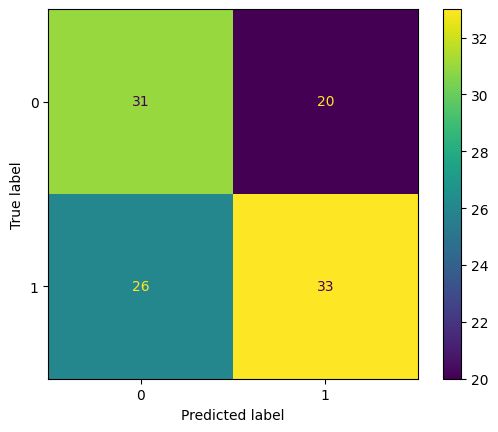

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, knn.predict(X_test),
                                        display_labels=['0', '1']);

The model is essentially uniformly guessing because there is the same probability for each outcome.

#Trying Logistic Regression Instead

I am trying logistic regression (also a classifier) to see if it performs more accurately in comparison to the last classifier I tried (KNN)

In [ ]:
logistic_regression_model = LogisticRegression(max_iter = 1000, random_state=42)
logistic_regression_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
#Testing
y_pred = logistic_regression_model.predict(X_test)
#print(y_pred)

accuracy = np.sum(np.abs(y_pred-y_test)) / len(y_pred) #need to find the difference (absolute value) divided by length of our predictions
print(accuracy)

0.35454545454545455


#Trying Perceptrons Instead

I am trying another classifier, known as Perceptrons, to see if it performs more accurately in comparison to the KNN and Logistic Regression classifiers.

In [ ]:
perceptron_model = Perceptron(max_iter = 1000, eta0 = 0.1, random_state=42) #42 can be changed later in the model if I want
perceptron_model.fit(X_train, y_train) #pass in your training data

Perceptron(eta0=0.1, random_state=42)

In [ ]:
#Testing
y_pred = perceptron_model.predict(X_test)
#print(y_pred)

accuracy = np.sum(np.abs(y_pred-y_test)) / len(y_pred) #need to find the difference (absolute value) divided by length of our predictions
print(accuracy)

0.41818181818181815


# Trying to predict sex instead of season

Perhaps, season cannot really be predicted using these features but the paper this dataset comes from (Schwarz et al., 2018) stated that there was a statistically significant difference in diet proportions between sexes. If there was a statistically significant difference, it is possible that we might be able to predict the label 'male' or 'female' using a model. I will try to predict sex using a KNN classifier because this is the model I initially felt was best suited.

In [ ]:
# Initialize the data arrays as numpy arrays
X = df[ ['SiteIndex', 'SeasonIndex', 'Ad_Atlantic_Salmon', 'Ad_cutthroat_trout',
         'Ad_dolly_varden', 'Ad_Chinook_salmon', 'Ad_chum_salmon',
         'Ad_coho_salmon', 'Ad_pink_salmon', 'Ad_sockeye_salmon', 'Ad_steelhead',
         'American_Shad', 'Atka_Mackerel', 'Bathyraja_interrupta', 'Bay_Goby',
         'Bering_Flounder', 'Big_Skate', 'Blackbelly_Eelpout', 'Buffalo_Sculpin',
         'Butter_Sole', 'Cabezon', 'California_Market_Squid', 'Capelin',
         'China_Rockfish', 'Dover_Sole', 'Dungeness_crab', 'English_Sole',
         'Eulachon', 'Giant_Pacific_Octopus', 'Giant_Wrymouth', 'Great_Sculpin',
         'Juv_Atlantic_salmon', 'Juv_Chinook_salmon', 'Juv_chum_salmon',
         'Juv_coho_salmon', 'Juv_cutthroat_trout', 'Juv_dolly_varden', 'Juv_pink_salmon_',
         'Juv_sockeye_salmon', 'Juv_steelhead', 'Kelp_Greenling', 'Lingcod',
         'Longfin_Smelt', 'Longspine_Combfish', 'Magister_armhook_squid', 'Northern_Anchovy',
         'Northern_Clingfish', 'Northern_Smoothtongue', 'Pacific_Cod', 'Pacific_Hake',
         'Pacific_Halibut', 'Pacific_Herring', 'Pacific_Red_Octopus',
         'Pacific_Sand_Lance', 'Pacific_Sandfish', 'Pacific_Staghorn_Sculpin',
         'Pacific_Tomcod', 'Padded_Sculpin', 'Pile_Surfperch', 'Plainfin_Midshipman',
         'Prickly_Sculpin', 'Puget_Sound_Rockfish', 'Red_Irish_Lord', 'River_Lamprey',
         'Rock_Gunnel', 'Sablefish', 'Saddleback_Gunnel', 'Sand_Sole',
         'Shiner_Surfperch', 'Snake_Prickleback', 'Speckled_Sanddab',
         'Spiny_Dogfish', 'Spotted_Ratfish', 'Starry_Flounder', 'Striped_Surfperch',
         'Surf_Smelt', 'Tadpole_Sculpin', 'Threespine_Stickleback',
         'Walleye_Pollock', 'Whitebait_Smelt', 'Whitespotted_Greenling', 'Wolf_Eel'] ]
         #In pandas, I can specificy which variables / columns you want.
         #The 'to_numpy' makes it a matrix.
y = df['SexIndex'].to_numpy()

In [ ]:
#Normalize the data
#X = (X - X.mean()) / X.std()
#X = np.nan_to_num(X, nan=0.0)

In [ ]:
#Split data into test and train data
#stratify=y to state that we want roughly equal proportions
# 20% of data for testing and 80% of data for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(np.sum(y_train)/len(y_train))
print(np.sum(y_test)/len(y_test))

0.4759725400457666
0.4727272727272727


In [ ]:
# create the knn object
knn = KNeighborsClassifier(n_neighbors=3) #have to specify how many neighbors we want
knn.fit(X_train, y_train) #the function to use for the model to actually know something about the data

KNeighborsClassifier(n_neighbors=3)

In [ ]:
#Testing
y_pred = knn.predict(X_test)
#print(y_pred)

accuracy = np.sum(np.abs(y_pred-y_test)) / len(y_pred) #need to find the difference (absolute value) divided by length of our predictions
print(accuracy)

0.4090909090909091


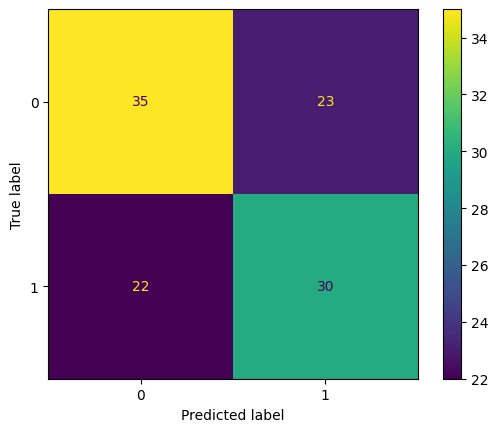

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, knn.predict(X_test),
                                        display_labels=['0', '1']);

# Implementing XGBoost and Trying to Predict Season using all other features

I will now try using XGBoost, which utilizes gradient boosting to improve on examples that the model got wrong. It finds what the model performed poorly on and tries to make improvements in the next iteration. Gradient boosting works by adding new models instead of updating parameters. The loss function is built into XGBoost and the default is regression with squared loss, also known as L2 loss (Euclidean distance). I will then use SHAP analysis to determine which features are most important for predicting Season. Knowing which features are most important can then be helpful to implement into any model.

In [ ]:
import xgboost as xgb
import shap

In [ ]:
X = np.column_stack([df['SiteIndex'], df['SexIndex'], df['Ad_Atlantic_Salmon'], df['Ad_cutthroat_trout'],
         df['Ad_dolly_varden'], df['Ad_Chinook_salmon'], df['Ad_chum_salmon'],
         df['Ad_coho_salmon'], df['Ad_pink_salmon'], df['Ad_sockeye_salmon'], df['Ad_steelhead'],
         df['American_Shad'], df['Atka_Mackerel'], df['Bathyraja_interrupta'], df['Bay_Goby'],
         df['Bering_Flounder'], df['Big_Skate'], df['Blackbelly_Eelpout'], df['Buffalo_Sculpin'],
         df['Butter_Sole'], df['Cabezon'], df['California_Market_Squid'], df['Capelin'],
         df['China_Rockfish'], df['Dover_Sole'], df['Dungeness_crab'], df['English_Sole'],
         df['Eulachon'], df['Giant_Pacific_Octopus'], df['Giant_Wrymouth'], df['Great_Sculpin'],
         df['Juv_Atlantic_salmon'], df['Juv_Chinook_salmon'], df['Juv_chum_salmon'],
         df['Juv_coho_salmon'], df['Juv_cutthroat_trout'], df['Juv_dolly_varden'], df['Juv_pink_salmon_'],
         df['Juv_sockeye_salmon'], df['Juv_steelhead'], df['Kelp_Greenling'], df['Lingcod'],
         df['Longfin_Smelt'], df['Longspine_Combfish'], df['Magister_armhook_squid'], df['Northern_Anchovy'],
         df['Northern_Clingfish'], df['Northern_Smoothtongue'], df['Pacific_Cod'], df['Pacific_Hake'],
         df['Pacific_Halibut'], df['Pacific_Herring'], df['Pacific_Red_Octopus'],
         df['Pacific_Sand_Lance'], df['Pacific_Sandfish'], df['Pacific_Staghorn_Sculpin'],
         df['Pacific_Tomcod'], df['Padded_Sculpin'], df['Pile_Surfperch'], df['Plainfin_Midshipman'],
         df['Prickly_Sculpin'], df['Puget_Sound_Rockfish'], df['Red_Irish_Lord'], df['River_Lamprey'],
         df['Rock_Gunnel'], df['Sablefish'], df['Saddleback_Gunnel'], df['Sand_Sole'],
         df['Shiner_Surfperch'], df['Snake_Prickleback'], df['Speckled_Sanddab'],
         df['Spiny_Dogfish'], df['Spotted_Ratfish'], df['Starry_Flounder'], df['Striped_Surfperch'],
         df['Surf_Smelt'], df['Tadpole_Sculpin'], df['Threespine_Stickleback'],
         df['Walleye_Pollock'], df['Whitebait_Smelt'], df['Whitespotted_Greenling'], df['Wolf_Eel']])
y = df['SeasonIndex']

In [ ]:
# create the XGBoost Classifier model here (I want a Classifier, NOT a Regressor)
model_XGBoost = xgb.XGBClassifier(n_estimators=200,
                         max_depth=10,
                         random_state=51,
                         learning_rate=0.05,
                         subsample=0.6,
                         colsample_bytree=0.8)
model_XGBoost.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_test = model_XGBoost.predict(X_test)
y_pred_train = model_XGBoost.predict(X_train)

Seeing what our results looks like:

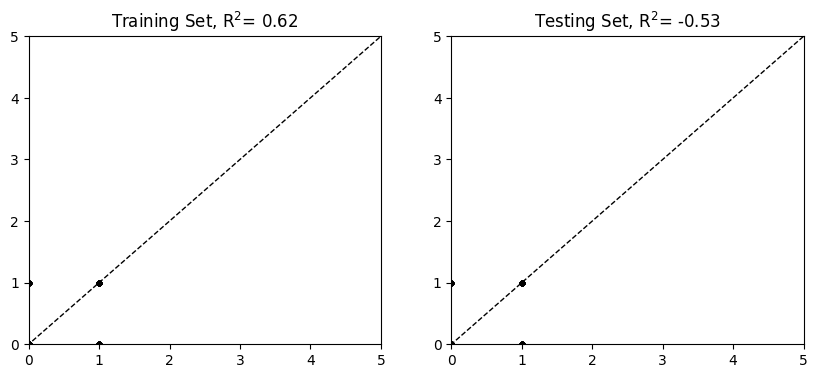

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(y_train, y_pred_train, 'k.')
plt.plot([-5, 80], [-5, 80],'k--',linewidth=1)
plt.xlim([0, 5])
plt.ylim([0, 5])
plt.ylabel('')
plt.xlabel('')
plt.title(f"Training Set, R$^2$= {r2_score(y_train, y_pred_train):.2f}")

plt.subplot(1,2,2)
plt.plot(y_test, y_pred_test, 'k.')
plt.plot([-5, 80], [-5, 80],'k--',linewidth=1)
plt.xlim([0, 5])
plt.ylim([0, 5])
plt.xlabel('')
plt.title(f"Testing Set, R$^2$= {r2_score(y_test, y_pred_test):.2f}");

plt.show()

SHAP Analysis to Explore Feature Importance

In [ ]:
explainer = shap.Explainer(model_XGBoost, X_train)
shap_values = explainer(X_test)
shap_values.feature_names = ['SiteIndex', 'SexIndex', 'Ad_Atlantic_Salmon', 'Ad_cutthroat_trout',
         'Ad_dolly_varden', 'Ad_Chinook_salmon', 'Ad_chum_salmon',
         'Ad_coho_salmon', 'Ad_pink_salmon', 'Ad_sockeye_salmon', 'Ad_steelhead',
         'American_Shad', 'Atka_Mackerel', 'Bathyraja_interrupta', 'Bay_Goby',
         'Bering_Flounder', 'Big_Skate', 'Blackbelly_Eelpout', 'Buffalo_Sculpin',
         'Butter_Sole', 'Cabezon', 'California_Market_Squid', 'Capelin',
         'China_Rockfish', 'Dover_Sole', 'Dungeness_crab', 'English_Sole',
         'Eulachon', 'Giant_Pacific_Octopus', 'Giant_Wrymouth', 'Great_Sculpin',
         'Juv_Atlantic_salmon', 'Juv_Chinook_salmon', 'Juv_chum_salmon',
         'Juv_coho_salmon', 'Juv_cutthroat_trout', 'Juv_dolly_varden', 'Juv_pink_salmon_',
         'Juv_sockeye_salmon', 'Juv_steelhead', 'Kelp_Greenling', 'Lingcod',
         'Longfin_Smelt', 'Longspine_Combfish', 'Magister_armhook_squid', 'Northern_Anchovy',
         'Northern_Clingfish', 'Northern_Smoothtongue', 'Pacific_Cod', 'Pacific_Hake',
         'Pacific_Halibut', 'Pacific_Herring', 'Pacific_Red_Octopus',
         'Pacific_Sand_Lance', 'Pacific_Sandfish', 'Pacific_Staghorn_Sculpin',
         'Pacific_Tomcod', 'Padded_Sculpin', 'Pile_Surfperch', 'Plainfin_Midshipman',
         'Prickly_Sculpin', 'Puget_Sound_Rockfish', 'Red_Irish_Lord', 'River_Lamprey',
         'Rock_Gunnel', 'Sablefish', 'Saddleback_Gunnel', 'Sand_Sole',
         'Shiner_Surfperch', 'Snake_Prickleback', 'Speckled_Sanddab',
         'Spiny_Dogfish', 'Spotted_Ratfish', 'Starry_Flounder', 'Striped_Surfperch',
         'Surf_Smelt', 'Tadpole_Sculpin', 'Threespine_Stickleback',
         'Walleye_Pollock', 'Whitebait_Smelt', 'Whitespotted_Greenling', 'Wolf_Eel']

In [ ]:
shap_values.base_values[0]

np.float64(-0.24312701988388788)

In [ ]:
print(np.shape(shap_values.values))
print(np.shape(X_test))

(110, 82)
(110, 82)


In [ ]:
X_test #colon 1 gives me up to the first row

,SiteIndex,SeasonIndex,Ad_Atlantic_Salmon,Ad_cutthroat_trout,Ad_dolly_varden,Ad_Chinook_salmon,Ad_chum_salmon,Ad_coho_salmon,Ad_pink_salmon,Ad_sockeye_salmon,...,Spotted_Ratfish,Starry_Flounder,Striped_Surfperch,Surf_Smelt,Tadpole_Sculpin,Threespine_Stickleback,Walleye_Pollock,Whitebait_Smelt,Whitespotted_Greenling,Wolf_Eel
279,0,1,0.0,0.0,0.0,1.759531,83.577713,0.000000,3.225806,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0
397,1,1,0.0,0.0,0.0,10.032448,0.203433,0.000000,0.107070,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0
382,1,1,0.0,0.0,0.0,0.027065,0.378909,0.054130,0.568363,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,98.585859,0.0,0.0,0
540,1,1,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,2.182540,0.0,0.0,0
220,0,1,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,1,1,0.0,0.0,0.0,0.090789,0.012970,0.000000,0.038910,0.609584,...,0.0,0.0,0.0,0.0,0.0,0.0,12.390888,0.0,0.0,0
119,0,1,0.0,0.0,0.0,0.000000,0.000000,0.972222,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0
466,1,0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,14.285714,0.0,0.0,0
235,0,1,0.0,0.0,0.0,4.375000,0.000000,4.375000,4.375000,26.250000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0


In [ ]:
model_XGBoost.predict(X_test)

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0])

In [ ]:
shap_values.values[:1,:]

array([[ 2.10074847e-01, -3.41498147e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  5.85691144e-01,
         1.91048837e+00,  1.90489911e-03, -5.70217411e-01,
        -2.67095820e-02,  0.00000000e+00,  5.06633632e-04,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.45759869e-02, -8.80038437e-03,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -4.61849421e-04,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  8.70804757e-03,
         3.28260157e-03,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -8.69185449e-02,
         2.93514162e-03, -1.86802464e-02,  0.00000000e+00,
         0.00000000e+00,  8.08016042e-02, -4.17399464e-02,
         1.04455809e-03,  0.00000000e+00,  2.91950115e-02,
         0.00000000e+00,  0.00000000e+00, -6.47612382e-03,
         0.00000000e+00,  0.00000000e+00, -5.78143982e-03,
         0.00000000e+00, -3.39488601e-02,  0.00000000e+0

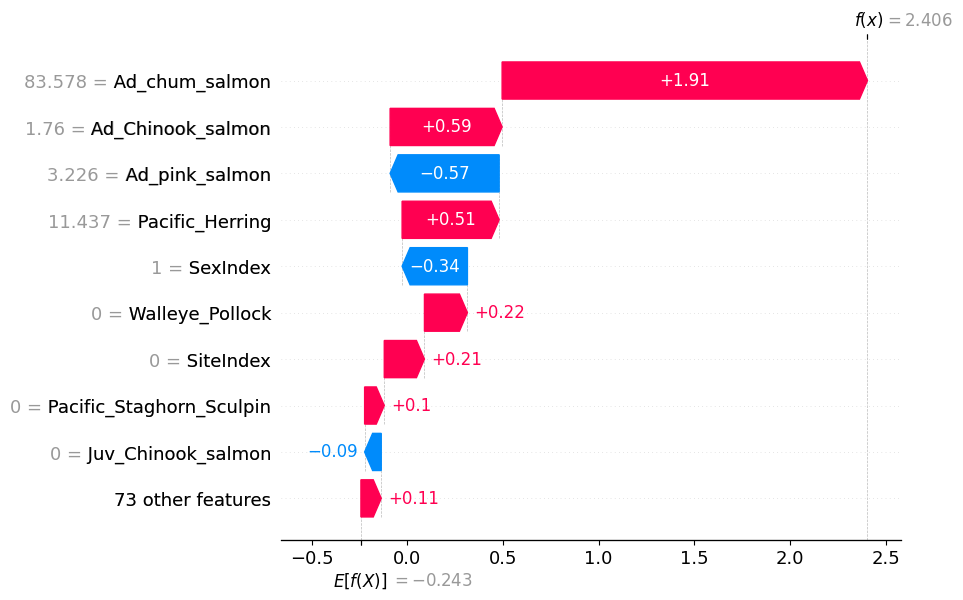

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
shap_values.base_values[0] + np.sum(shap_values.values[:1,:])

np.float64(2.405644121643272)

In [ ]:
np.mean(np.abs(shap_values.values), axis=0)

array([0.18846255, 0.42238207, 0.        , 0.        , 0.        ,
       0.23244608, 0.21748644, 0.0078517 , 0.1869495 , 0.07857335,
       0.        , 0.00127079, 0.        , 0.        , 0.        ,
       0.01603464, 0.02548888, 0.        , 0.        , 0.        ,
       0.        , 0.00158189, 0.        , 0.        , 0.        ,
       0.        , 0.01494036, 0.00459773, 0.        , 0.        ,
       0.        , 0.        , 0.20177215, 0.0403008 , 0.06368765,
       0.        , 0.        , 0.09505907, 0.12299776, 0.00433848,
       0.        , 0.02325246, 0.        , 0.        , 0.01105899,
       0.        , 0.        , 0.02139315, 0.        , 0.27223846,
       0.        , 0.34474227, 0.        , 0.        , 0.        ,
       0.14852304, 0.        , 0.        , 0.        , 0.05135308,
       0.        , 0.        , 0.        , 0.03405435, 0.        ,
       0.        , 0.        , 0.        , 0.06452902, 0.01865256,
       0.        , 0.        , 0.00059959, 0.01417182, 0.     

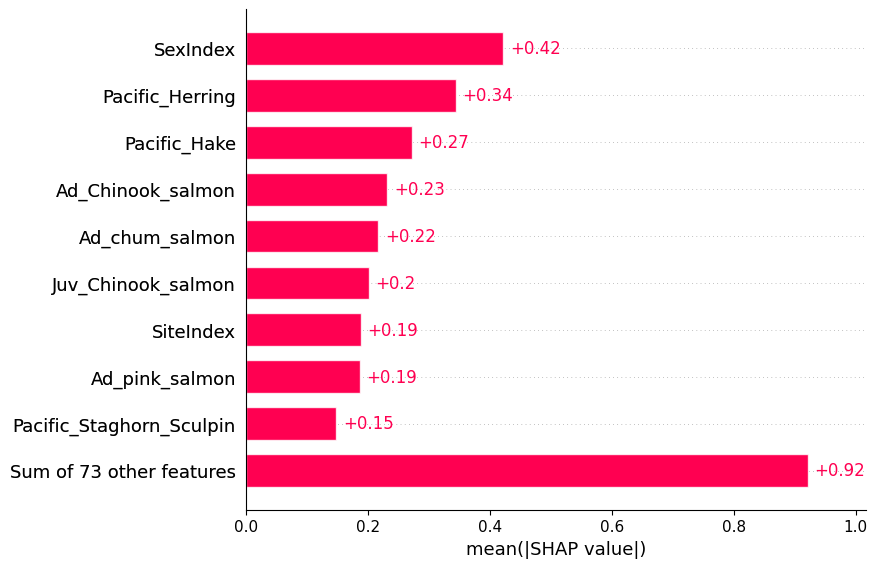

In [ ]:
shap.plots.bar(shap_values)

# `Calculating XGBoost Model Accuracy`

In [ ]:
#Testing
y_pred = model_XGBoost.predict(X_test)
#print(y_pred)

accuracy = np.sum(np.abs(y_pred-y_test)) / len(y_pred) #need to find the difference (absolute value) divided by length of our predictions
print(accuracy)

0.38181818181818183


The model is only accurate 38.18% of the time - which indicates that this is not a great model.

# Conducting a Confusion Matrix for XGBoost

Remember that Spring is assigned 0. Fall is assigned 1.

[1 1 0 1 0 1 0 0 1 0 0 0 0 0 1 1 1 1 1 1 0 0 0 1 0 0 0 1 1 1 0 1 1 1 0 1 0
 1 0 0 1 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1 1 1 0 1 1 0 1
 0 1 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0]
[1 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1 0 1 1 1 0 1 0
 1 0 1 1 0 1 0 1 0 1 1 0 1 1 1 0 0 0 0 0 1 1 0 0 0 1 1 1 1 1 1 1 0 1 0 0 0
 0 1 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 1 0]


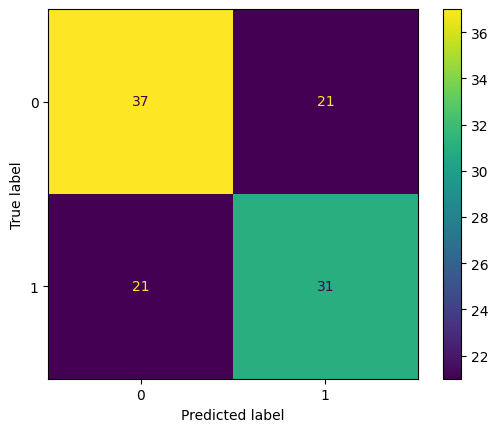

In [ ]:
print(y_test)
print(model_XGBoost.predict(X_test))
ConfusionMatrixDisplay.from_predictions(y_test, model_XGBoost.predict(X_test),
                                        display_labels=['0', '1']);

37 were truly spring and accurately predicted to be spring. 31 were truly fall and accurately predicted to be fall. 21 were truly spring and inaccurately predicted to be fall. 21 were truly fall and inaccurately predicted to be spring. Therefore, this confusion matrix tells us that the model is still not very successful.

I am going to use the top 5 most important features to implement another XGBoost Classifier and see if it is more successful at predicting Season.

# Creating a second XGBoost Model using the top 5 most important predictive features

Using the shap.plots.bar, I am implementing the top 5 most important predictive features:

In [ ]:
X = np.column_stack([df['SexIndex'], df['Pacific_Herring'], df['Pacific_Hake'], df['Ad_Chinook_salmon'],
         df['Ad_chum_salmon']])
y = df['SeasonIndex']

In [ ]:
# create a second XGBoost Classifier model here that only has the top 5 important features
model_XGBoost_2 = xgb.XGBClassifier(n_estimators=200,
                         max_depth=10,
                         random_state=51,
                         learning_rate=0.05,
                         subsample=0.6,
                         colsample_bytree=0.8)
model_XGBoost_2.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_test = model_XGBoost.predict(X_test)
y_pred_train = model_XGBoost.predict(X_train)

Seeing what our results look like:

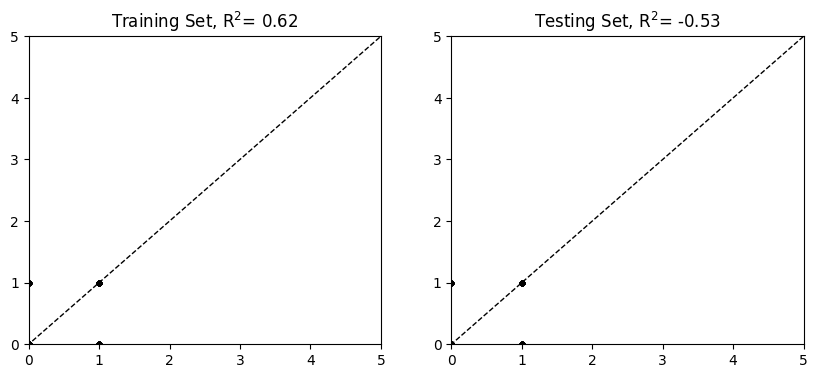

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(y_train, y_pred_train, 'k.')
plt.plot([-5, 80], [-5, 80],'k--',linewidth=1)
plt.xlim([0, 5])
plt.ylim([0, 5])
plt.ylabel('')
plt.xlabel('')
plt.title(f"Training Set, R$^2$= {r2_score(y_train, y_pred_train):.2f}")

plt.subplot(1,2,2)
plt.plot(y_test, y_pred_test, 'k.')
plt.plot([-5, 80], [-5, 80],'k--',linewidth=1)
plt.xlim([0, 5])
plt.ylim([0, 5])
plt.xlabel('')
plt.title(f"Testing Set, R$^2$= {r2_score(y_test, y_pred_test):.2f}");

plt.show()

# `Calculating the second XGBoost Model's Accuracy`(the XGBoost model with less predictive features)

In [ ]:
#Testing
y_pred = model_XGBoost_2.predict(X_test)
#print(y_pred)

accuracy = np.sum(np.abs(y_pred-y_test)) / len(y_pred) #need to find the difference (absolute value) divided by length of our predictions
print(accuracy)

0.38181818181818183


# Making a Confusion Matrix for XGBoost_2

Remember that Spring is assigned 0. Fall is assigned 1.

[1 1 0 1 0 1 0 0 1 0 0 0 0 0 1 1 1 1 1 1 0 0 0 1 0 0 0 1 1 1 0 1 1 1 0 1 0
 1 0 0 1 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1 1 1 0 1 1 0 1
 0 1 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0]
[1 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1 0 1 1 1 0 1 0
 1 0 1 1 0 1 0 1 0 1 1 0 1 1 1 0 0 0 0 0 1 1 0 0 0 1 1 1 1 1 1 1 0 1 0 0 0
 0 1 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 1 0]


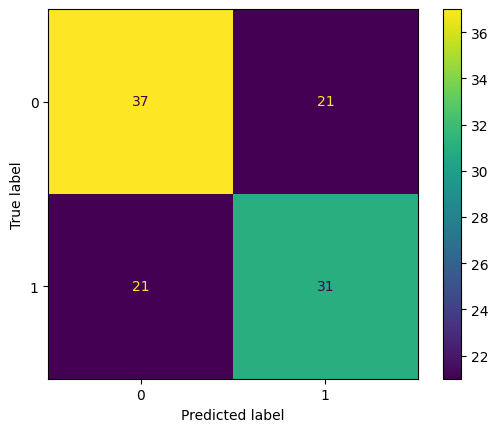

In [ ]:
print(y_test)
print(model_XGBoost_2.predict(X_test))
ConfusionMatrixDisplay.from_predictions(y_test, model_XGBoost.predict(X_test),
                                        display_labels=['0', '1']);

37 were truly spring and accurately predicted to be spring. 31 were truly fall and accurately predicted to be fall. 21 were truly spring and inaccurately predicted to be fall. 21 were truly fall and inaccurately predicted to be spring. Therefore, this confusion matrix tells us that the model is still not very successful.

# Using the 5 most important features determined from SHAP Analysis and implementing them into another KNN model

Let's create KNN_2

In [ ]:
# Initialize the data arrays as numpy arrays
X = df[ ['SexIndex', 'Pacific_Herring', 'Pacific_Hake', 'Ad_Chinook_salmon', 'Ad_chum_salmon'] ]
         #In pandas, I can specificy which variables / columns I want.
         #The 'to_numpy' makes it a matrix.
y = df['SeasonIndex'].to_numpy()

In [ ]:
 #Normalize the data
X = (X - X.mean()) / X.std()
X = np.nan_to_num(X, nan=0.0)

In [ ]:
#Split data into test and train data
#stratify=y to state that we want roughly equal proportions
# 20% of data for testing and 80% of data for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(np.sum(y_train)/len(y_train))
print(np.sum(y_test)/len(y_test))

0.5308924485125858
0.5363636363636364


In [ ]:
# create the knn object
knn_2 = KNeighborsClassifier(n_neighbors=24) #have to specify how many neighbors we want
knn_2.fit(X_train, y_train) #the function to use for the model to actually know something about the data

KNeighborsClassifier(n_neighbors=24)

In [ ]:
#Testing
y_pred = knn_2.predict(X_test)
#print(y_pred)

accuracy = np.sum(np.abs(y_pred-y_test)) / len(y_pred) #need to find the difference (absolute value) divided by length of our predictions
print(accuracy)

0.5


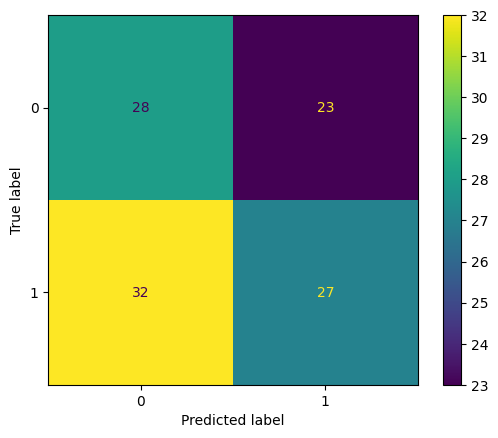

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, knn_2.predict(X_test),
                                        display_labels=['0', '1']);

28 were truly spring and predicted to be spring. 27 were truly fall and predicted to be fall. 23 were truly spring and predicted to be fall. 32 were truly fall and predicted to be spring.

# Some Notes on all these Models

When trying to predict season (fall or spring) using various models, here were their accuracies:
- KNN Model Accuracy = 41.82%
- Logistic Regression Accuracy = 35.45%
- Perceptron Model Accuracy = 41.82%
- XGBoost Model Accuracy = 38.18%
- XGBoost Model 2 (using only 5 most important predictive features) Accuracy = 38.18%
- KNN_2 Model (using 5 most important predictive features) = 50.00%

The second XGBoost model using the 5 most important predictive features has the same accuracy as the first XGBoost model including all the predictive features. This would make sense considering that the more important features contribute the most to both models. I also used the same random seed for both models.

The KNN model using the 5 most important predictive features is the most accurate model of all at 50.00% of the time.

# Scientific Interpretation

**Findings in the context of the science question:**
Diet cannot predict Season using my models and this dataset. The models are not accurate enough to have confidence in predictions. While there might be statistical differences when analyzing the data - there might not be enough data here to build a good predictive model. In addition, these data were obtained from study sites in Canada (Comox and Cowichan Bay). At these study sites, there might not be strong seasonal differences in prey availability. In future work, obtaining a dataset from an area like Elkhorn Slough might help build a better predictive model. This is because there are clearly recorded differences in prey availability with the seasons, with some species only using the slough as a nursery at some times of the year and with other species migrating in and out at specific times.


**Limitations in the model results:** The KNN model using the 5 most important features is the most accurate model of all that I implemented, but it is still only accurate 50.00% of the time. Most of the limitations are in the dataset. There are only around 550 observations in the dataset, whereas these models might need thousands of observations to be successful at predicting. Moreover, KNN suffers from the curse of dimensionality (Bellman, 1957), meaning, in high dimension, all points are 'nearest neighbors'. This is a limitation of the KNN model with many dimensions. A way to improve this is to use a lesser number of more important features.

**Describes paths forward for future work:** Pick a dataset with more data and more variance in the data as well. It would be good to look at other locations, include all four seasons (not just fall and spring), more age ranges, and anything in general that diversifies what the input data is so that the model generalizes better.


**References**

Bellman, R. (1957). Dynamic programming, princeton univ. Press Princeton, New Jersey, 39.

Schwarz, D., Spitzer, S. M., Thomas, A. C., Kohnert, C. M., Keates, T. R., & Acevedo‐Gutiérrez, A. (2018). Large‐scale molecular diet analysis in a generalist marine mammal reveals male preference for prey of conservation concern. Ecology and Evolution, 8(19), 9889-9905. https://doi.org/10.1002/ece3.4474
